In [ ]:
!pip install langgraph

In [24]:
from typing import TypedDict
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemorySaver

In [18]:
# Create state schema
class AgentState(TypedDict):
  messages: str


In [48]:
# listen function
def listen():
  return "I hear You\n"
def voice_output(text):
  return f"You said: {text}\n"

In [49]:

# create nodes-> Defined function that perfoms one task
def transcribe(state: AgentState)-> AgentState:
  """Responsible for transcribing audio to text data"""
  text=listen()
  # update the state
  state['messages']=state['messages']+text
  return state

# next node call the LLM
def run_llm(state: AgentState)-> AgentState:
  """Pass the user input into the LLM"""
  llm=f"AI got: {state['messages']}"
  # LLM has an MCP server and decides if to make call
  state['messages']=state['messages']+llm
  return state

def speak(state: AgentState)-> AgentState:
  """Speak the output back to the user"""
  voice_output(state['messages'])
  return state


In [50]:
# create the graph
graph=StateGraph(AgentState)

# add our nodes(functions)
graph.add_node('listen_transcribe', transcribe)
graph.add_node('LLM_Execute_MCP', run_llm)
graph.add_node('speak', speak)

# add edges to connect the nodes and tell graph what to execute next
graph.add_edge('listen_transcribe', 'LLM_Execute_MCP')
graph.add_edge('LLM_Execute_MCP', 'speak')

graph.set_entry_point('listen_transcribe')
graph.set_finish_point('speak')

# the memory we will use
memory=MemorySaver()

# compile the graph to an executable
app=graph.compile(
    checkpointer=memory
)


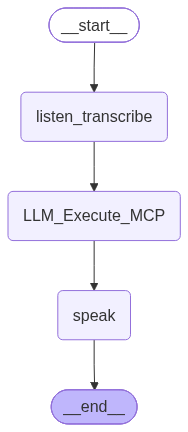

In [51]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [52]:
# After adding memory we need to set up the threat_id
# Each conversation has a different thread_id and LangGraph will
# call each one with its unique id
config={
    "configurable":{
        "thread_id":"user1"
    }
}

app.invoke({"messages":""},config=config)

{'messages': 'I hear You\nAI got: I hear You\n'}